# ARTI 560 - Computer Vision

# Visual Representations with DINOv2 - Exercise

## Exercise 1: Unsupervised Clustering

In this exercise, you will use the KMeans algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

### Instructions:

1. Extract the 384-dimensional `[CLS]` tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering (`n_clusters = 2`) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

model_id = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)

model.eval()

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

In [3]:
dataset = OxfordIIITPet(
    root="/kaggle/working",
    split="trainval",
    target_types="binary-category",
    download=True
)

print("Dataset size:", len(dataset))

100%|██████████| 792M/792M [00:22<00:00, 35.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.5MB/s]


Dataset size: 3680


In [4]:
images = []
labels = []

cat_count = 0
dog_count = 0

for img, label in dataset:

    # 0 = cat, 1 = dog
    if label == 0 and cat_count < 10:
        images.append(img.convert("RGB"))
        labels.append(0)
        cat_count += 1

    elif label == 1 and dog_count < 10:
        images.append(img.convert("RGB"))
        labels.append(1)
        dog_count += 1

    if cat_count == 10 and dog_count == 10:
        break

print("Total images:", len(images))
print("Cats:", cat_count)
print("Dogs:", dog_count)

Total images: 20
Cats: 10
Dogs: 10


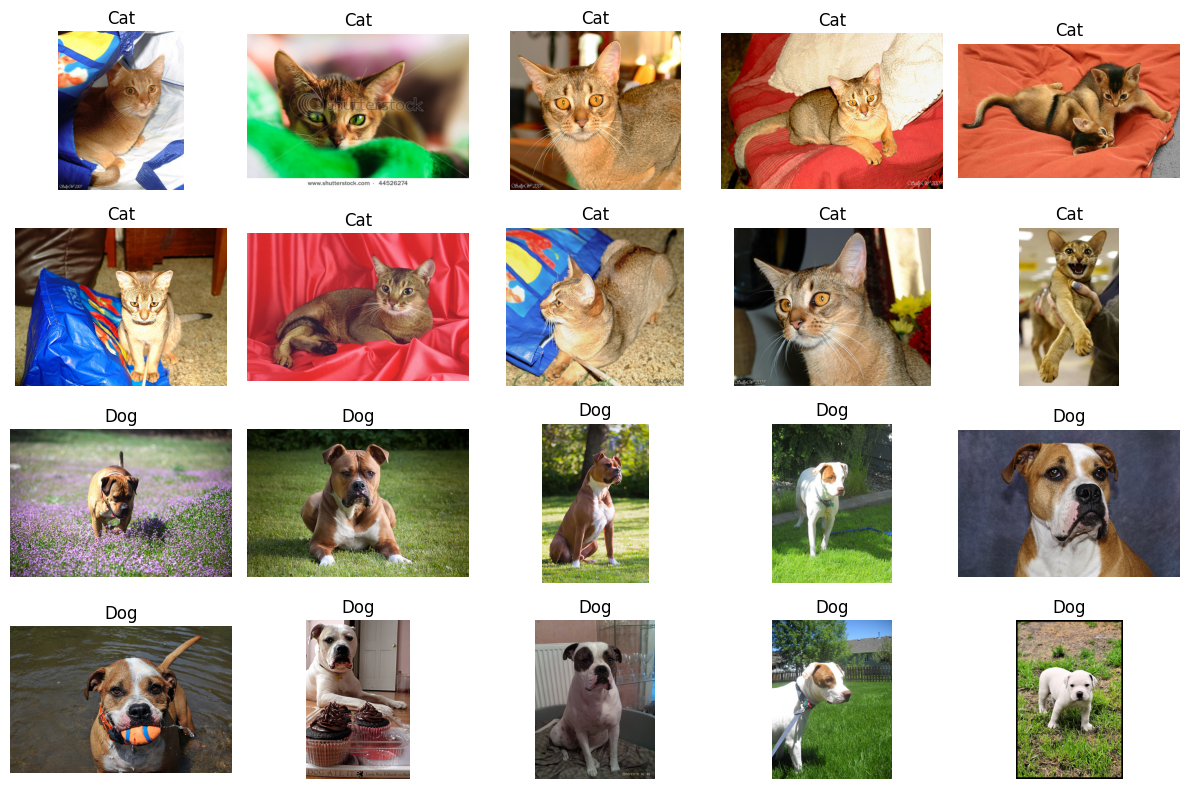

In [5]:
plt.figure(figsize=(12, 8))

for i, img in enumerate(images):

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    if labels[i] == 0:
        plt.title("Cat")
    else:
        plt.title("Dog")

plt.tight_layout()
plt.show()

In [6]:
features = []

with torch.no_grad():

    for img in images:

        inputs = processor(
            images=img,
            return_tensors="pt"
        ).to(device)

        outputs = model(**inputs)

        # CLS token
        cls_token = outputs.last_hidden_state[:, 0, :]

        features.append(
            cls_token.cpu().numpy().squeeze()
        )

features = np.array(features)

print("Feature shape:", features.shape)

Feature shape: (20, 384)


In [7]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

pred_clusters = kmeans.fit_predict(features)

print("Predicted clusters:")
print(pred_clusters)

Predicted clusters:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [8]:
true_labels = np.array(labels)


acc1 = accuracy_score(true_labels, pred_clusters)
acc2 = accuracy_score(true_labels, 1 - pred_clusters)

best_accuracy = max(acc1, acc2)

print("Best Clustering Accuracy:", best_accuracy)

Best Clustering Accuracy: 1.0


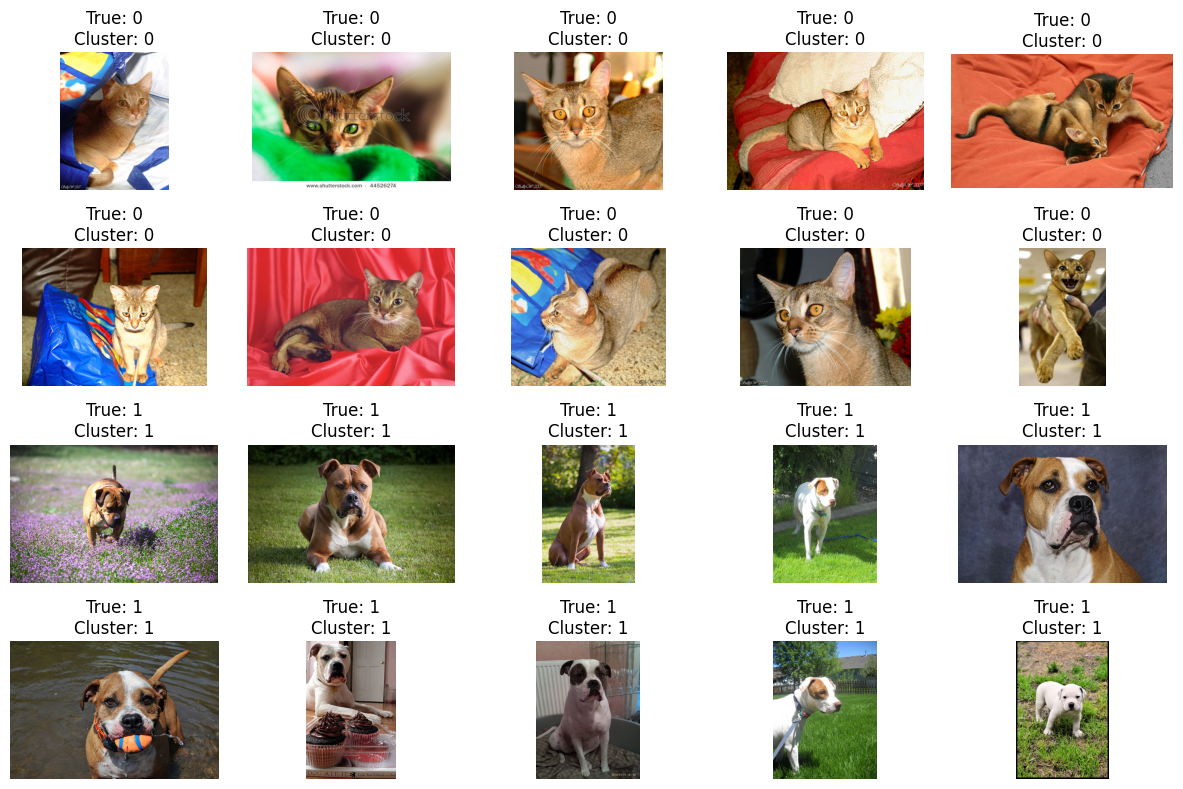

In [9]:
plt.figure(figsize=(12, 8))

for i, img in enumerate(images):

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"True: {labels[i]}\nCluster: {pred_clusters[i]}"
    )

plt.tight_layout()
plt.show()

## Exercise 2: Image Classification with DINOv2

In this exercise, you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

### Instructions:

For this exercise, you must use the following Model ID:

`facebook/dinov2-small-imagenet1k-1-layer`

Find an image online that belongs to one of the ImageNet-1k classes (e.g., Golden Retriever, school bus, coffee mug, grand piano).


In [10]:
import torch
import requests

from PIL import Image
from io import BytesIO

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification
)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)

model = AutoModelForImageClassification.from_pretrained(
    model_id
).to(device)

model.eval()

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

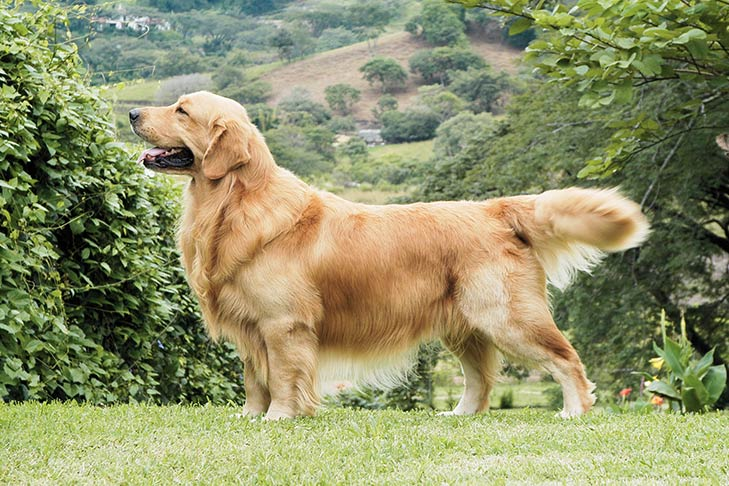

In [12]:
from PIL import Image

image_path = "/kaggle/input/datasets/elaffa/image1/golden retriever_1.jpg"

image = Image.open(image_path).convert("RGB")

image

In [13]:
inputs = processor(
    images=image,
    return_tensors="pt"
).to(device)

In [14]:
with torch.no_grad():

    outputs = model(**inputs)

    logits = outputs.logits

    predicted_class_id = logits.argmax(-1).item()

print(predicted_class_id)

207


In [15]:
# Ground-truth label
ground_truth = "golden retriever"

# Predicted label
predicted_label = model.config.id2label[
    predicted_class_id
]

print("Ground Truth Label:", ground_truth)
print("Predicted Label:", predicted_label)

Ground Truth Label: golden retriever
Predicted Label: golden retriever


### Comparison with Ground Truth

The uploaded image belongs to the ImageNet-1k class
“Golden Retriever”.

The model prediction was compared against the
ground-truth label to evaluate whether the
classification was correct.